<a href="https://colab.research.google.com/github/eyespydushyant/Census-Income-Classification/blob/main/_Adult_Income_Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Adult-Income-Classification-ML



##### **Project Type**    - Classification


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

**https://github.com/eyespydushyant/Census-Income-Classification**

# **Problem Statement**


**Write Problem Statement Here.**
The objective of this project is to build a Machine Learning Classification model that predicts whether an individual's annual income exceeds $50K based on demographic, educational, and employment-related information. By analyzing various socio-economic attributes such as age, education, occupation, marital status, working hours, and capital gain/loss, the model aims to classify individuals into one of two income categories: <=50K or >50K.

Accurate income prediction can help organizations and policymakers understand income distribution, identify factors affecting earnings, and support data-driven decision-making in areas such as employment, taxation, and social welfare programs.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

### Dataset Loading

In [ ]:
# Load Dataset
columns = [
    'age','workclass','fnlwgt','education','education-num',
    'marital-status','occupation','relationship','race',
    'sex','capital-gain','capital-loss','hours-per-week',
    'native-country','income'
]

df = pd.read_csv(
    "/content/adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)



### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 32561
Number of Columns : 15


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


#### Duplicate Values

In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 24


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()



,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:

# Check for null values %.
for col in df.columns:
  null_rate = df[col].isnull().sum() / len(df) * 100
  if null_rate > 0:
    print(f'The null values in {col} column are  {df[col].isnull().sum()} Percentage:- {null_rate}%')

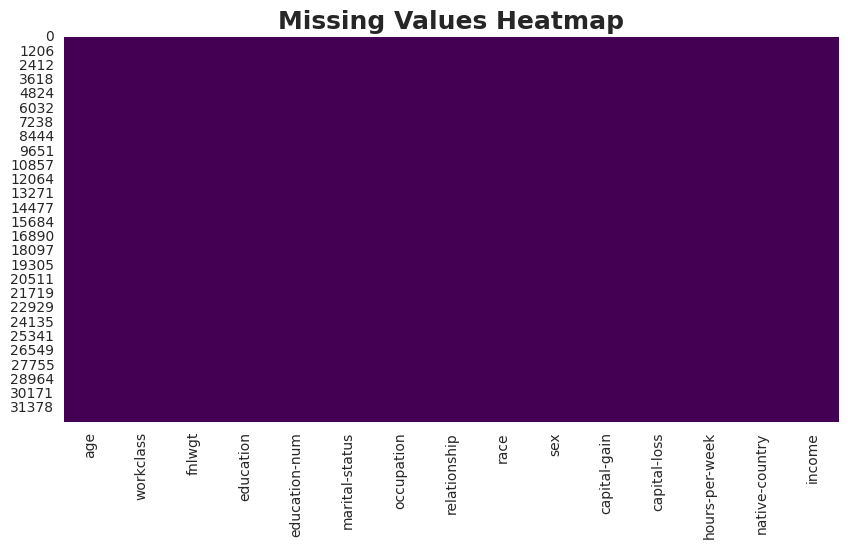

In [ ]:
# let's visualizing  the null values
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title(
    "Missing Values Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.show()

In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object


### What did you know about your dataset?



### **1. Dataset Overview**

- The Adult Income Dataset contains demographic, educational, and employment-related information collected from the **1994 U.S. Census Database**.
- Each row in the dataset represents information about a single individual.
- The dataset consists of **14 input features** and **1 target variable (Income)**.
- The objective of the project is to predict whether an individual's annual income is **greater than \$50K** or **less than or equal to \$50K**.
- It is one of the most widely used datasets for supervised machine learning classification tasks.

---

### **2. Data Types**

- The dataset contains both **numerical** and **categorical** features.
- Numerical features include:
  - Age
  - Fnlwgt
  - Education-num
  - Capital-gain
  - Capital-loss
  - Hours-per-week
- Categorical features include:
  - Workclass
  - Education
  - Marital-status
  - Occupation
  - Relationship
  - Race
  - Sex
  - Native-country
- Since machine learning models require numerical input, categorical variables must be encoded before model training.

---

### **3. Missing Values**

- The dataset contains missing values represented by the symbol **'?'** instead of actual null values.
- These missing values are mainly present in categorical columns.
- Before model building, these values should be replaced with **NaN** and handled appropriately using suitable preprocessing techniques.
- Proper treatment of missing values helps improve model performance and prediction accuracy.

---

### **4. Duplicate Records**

- The dataset may contain duplicate observations.
- Duplicate records can introduce bias during model training.
- Identifying and removing duplicate rows helps improve data quality and prevents unnecessary repetition.

---

### **5. Classification Problem**

- This is a **Supervised Machine Learning Classification** problem.
- The target variable is **Income**.
- Income has two categories:
  - **<=50K**
  - **>50K**
- The goal is to correctly classify individuals into one of these two income groups based on their demographic and employment-related information.

---

### **6. Feature Characteristics**

- The dataset contains a combination of demographic, educational, and occupational attributes.
- Several categorical variables contain multiple unique categories that require encoding.
- Numerical variables have different value ranges and should be standardized before applying distance-based algorithms such as **K-Nearest Neighbors (KNN)** and **Support Vector Machine (SVM)**.
- Some features may have stronger influence on income prediction than others, making feature selection and importance analysis valuable.

---

### **7. Business Understanding**

- Predicting income levels helps understand the relationship between education, occupation, work experience, and earnings.
- The project can assist governments, organizations, and researchers in analyzing socio-economic trends.
- Income prediction models can support workforce planning, economic research, policy making, and demographic analysis.
- The insights obtained from this dataset can also be used in recommendation systems, financial planning, and labor market studies.

---

### **8. Machine Learning Perspective**

- The dataset is suitable for applying various classification algorithms.
- Multiple machine learning models can be trained and compared to identify the best-performing classifier.
- Model evaluation metrics such as **Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix** can be used to measure model performance.
- Hyperparameter tuning can further improve prediction accuracy and model generalization.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.


for col in df.columns:
    print("="*60)
    print(f"Column : {col}")
    print(f"Number of Unique Values : {df[col].nunique()}")
    print(df[col].unique())
    print()

Column : age
Number of Unique Values : 73
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]

Column : workclass
Number of Unique Values : 9
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Column : fnlwgt
Number of Unique Values : 21648
[ 77516  83311 215646 ...  34066  84661 257302]

Column : education
Number of Unique Values : 16
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Column : education-num
Number of Unique Values : 16
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Column : marital-status
Number of Unique Values : 7
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-

In [ ]:
unique_df = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

unique_df

,Column,Unique Values
0,age,73
1,workclass,9
2,fnlwgt,21648
3,education,16
4,education-num,16
5,marital-status,7
6,occupation,15
7,relationship,6
8,race,5
9,sex,2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df.replace('?', np.nan, inplace=True)

In [ ]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': round(df.isnull().mean()*100,2)
})

missing.sort_values(by='Missing Values',ascending=False)

,Missing Values,Percentage
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79
fnlwgt,0,0.00
education,0,0.00
education-num,0,0.00
age,0,0.00
marital-status,0,0.00
relationship,0,0.00
sex,0,0.00


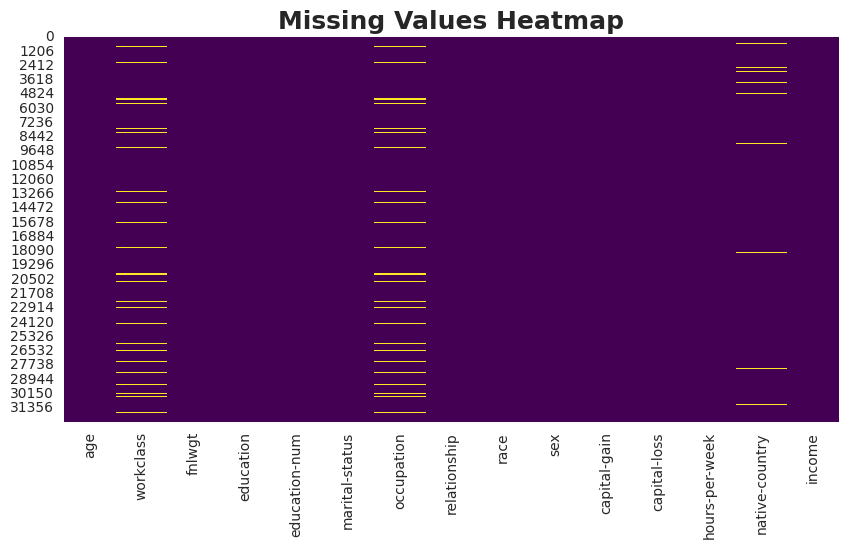

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title(
    "Missing Values Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.show()

In [ ]:
print("Duplicate Records :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates :", df.shape)

Duplicate Records : 24
Shape After Removing Duplicates : (32537, 15)


In [ ]:
categorical_cols = [
    'workclass',
    'occupation',
    'native-country'
]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
categorical_features = df.select_dtypes(include='object').columns

numerical_features = df.select_dtypes(exclude='object').columns

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

Numerical Features
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [ ]:
df['income'].value_counts()

,count
income,
<=50K,24698
>50K,7839


In [ ]:
round(df['income'].value_counts(normalize=True)*100,2)

,proportion
income,
<=50K,75.91
>50K,24.09


In [ ]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

df.head()

Rows : 32537
Columns : 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### What all manipulations have you done and insights you found?

### Observation

- The dataset contains both numerical and categorical features.
- Missing values were identified in a few categorical columns and replaced using the most frequent category (mode).
- Duplicate records were removed to improve data quality.
- No numerical missing values were found in the dataset.
- The target variable contains two income classes, making it a binary classification problem.
- The dataset is now clean and ready for exploratory data analysis and feature engineering.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

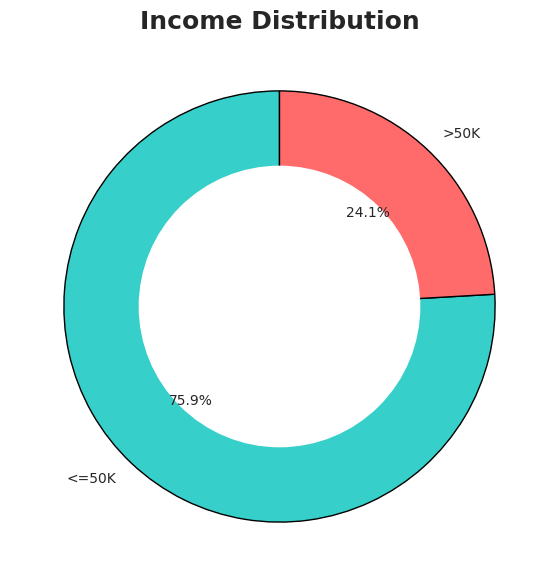

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(7,7))

colors=['#36CFC9','#FF6B6B']

plt.pie(
    df['income'].value_counts(),
    labels=df['income'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)

centre_circle=plt.Circle((0,0),0.65,fc='white')

fig=plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title(
    "Income Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

### Observation

- The target variable consists of two income categories.
- Most individuals earn **less than or equal to \$50K** annually.
- The dataset is moderately imbalanced.
- Class imbalance should be considered during model evaluation.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

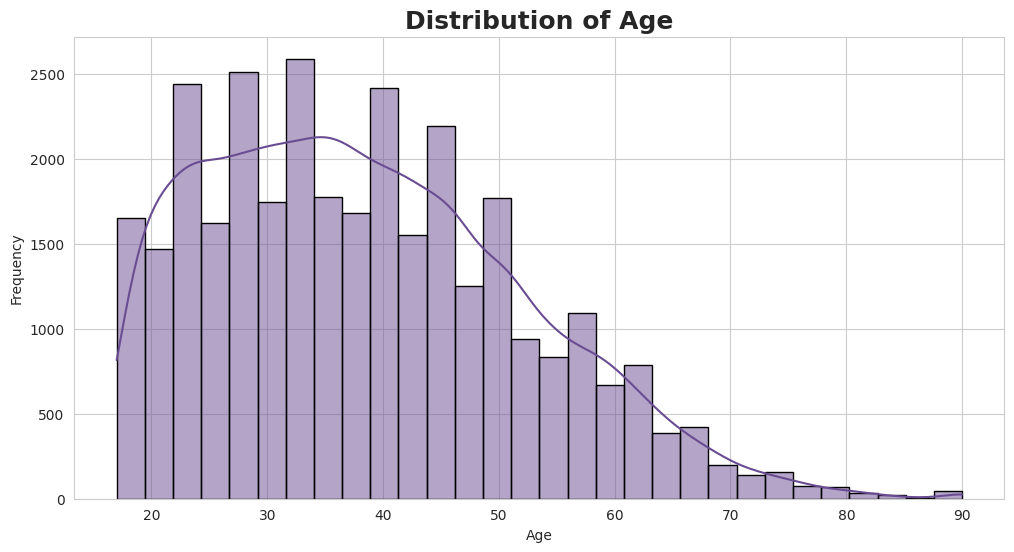

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(12,6))

sns.histplot(
    df['age'],
    bins=30,
    kde=True,
    color='#6A4C93',
    edgecolor='black'
)

plt.title(
    "Distribution of Age",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Most individuals are between **25 and 50 years** of age.
- The age distribution is positively skewed.
- Very young and elderly individuals represent a smaller proportion of the dataset.
- Age appears to be an important feature for income prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

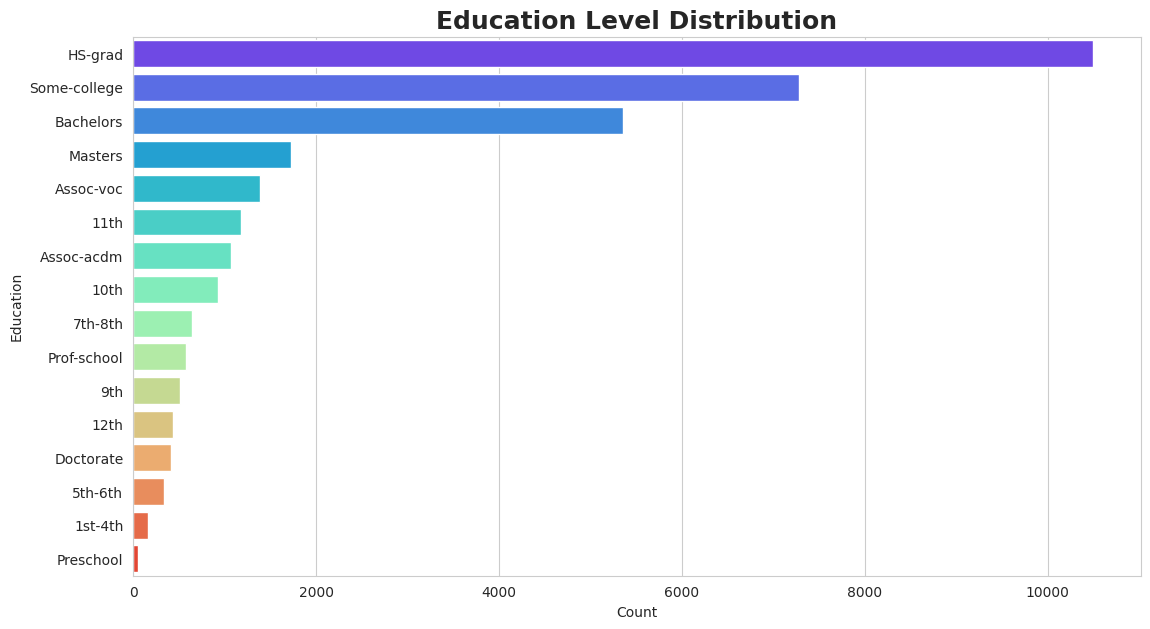

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(13,7))

order=df['education'].value_counts().index

sns.countplot(
    data=df,
    y='education',
    order=order,
    palette='rainbow'
)

plt.title(
    "Education Level Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Count")

plt.ylabel("Education")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- High School graduates constitute the largest group.
- Bachelor's and Some-college categories also contain a significant number of individuals.
- Higher education levels generally have fewer observations.
- Education is expected to influence annual income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

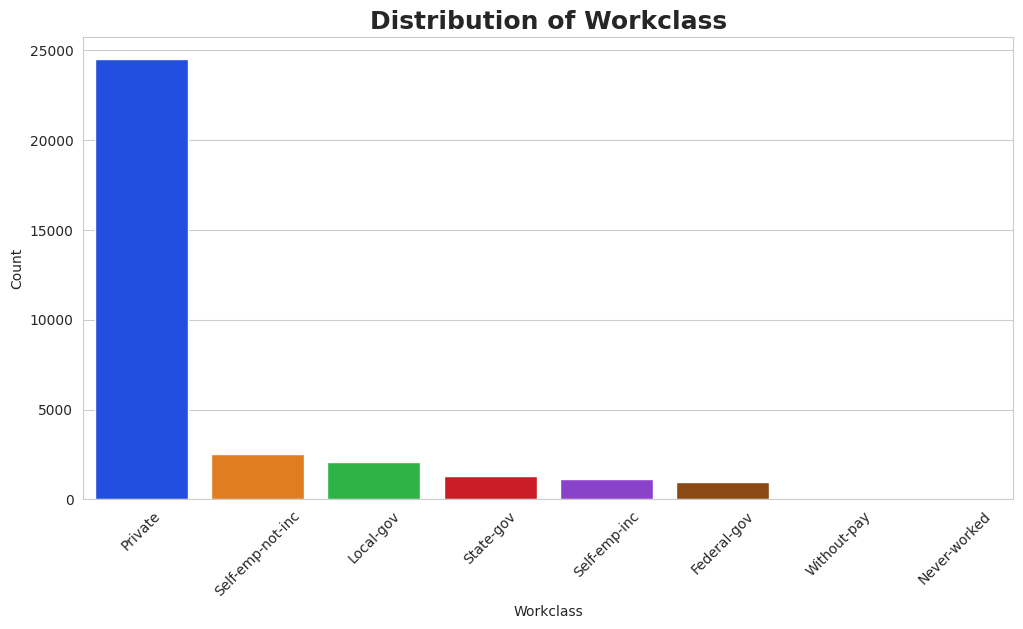

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='workclass',
    order=df['workclass'].value_counts().index,
    palette='bright'
)

plt.xticks(rotation=45)

plt.title(
    "Distribution of Workclass",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Workclass")

plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Most individuals work in the **Private** sector.
- Government and self-employed categories are less common.
- Some workclass categories contain relatively few observations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

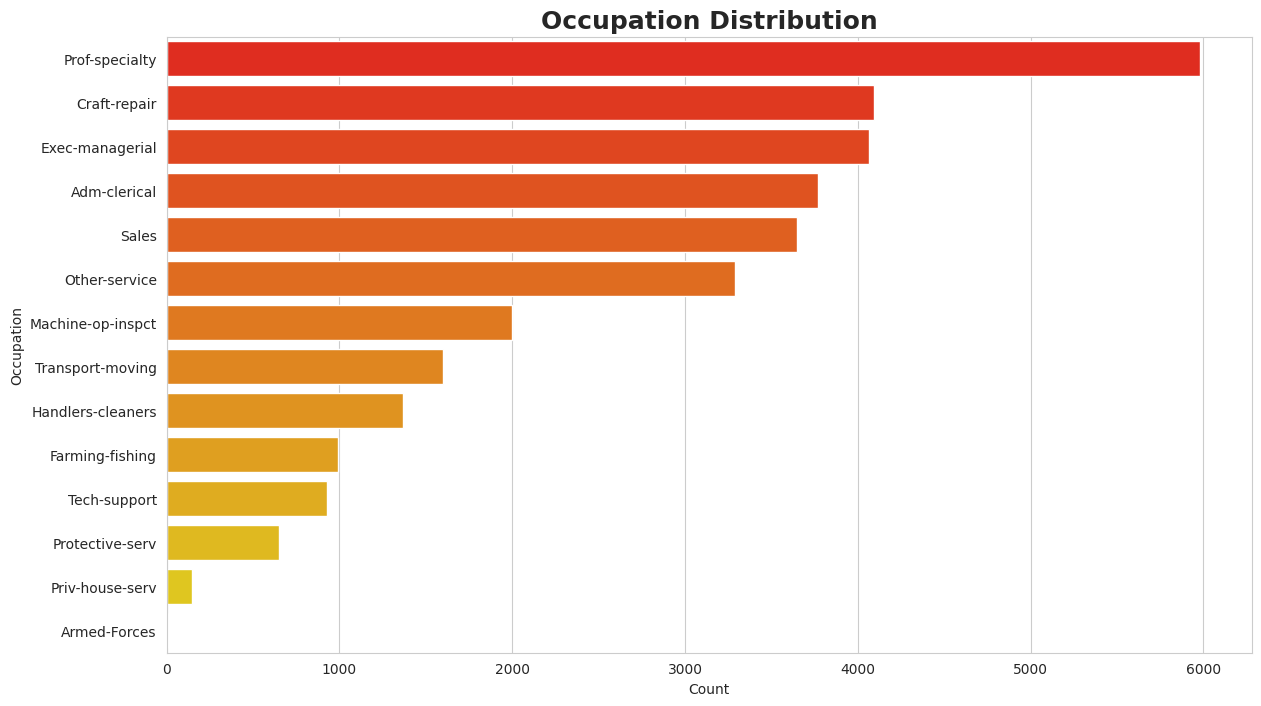

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y='occupation',
    order=df['occupation'].value_counts().index,
    palette='autumn'
)

plt.title(
    "Occupation Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Count")

plt.ylabel("Occupation")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?


### Observation

- The dataset contains a diverse range of occupations.
- Professional, technical, and craft-related occupations are the most common.
- Occupation is expected to be one of the strongest predictors of income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

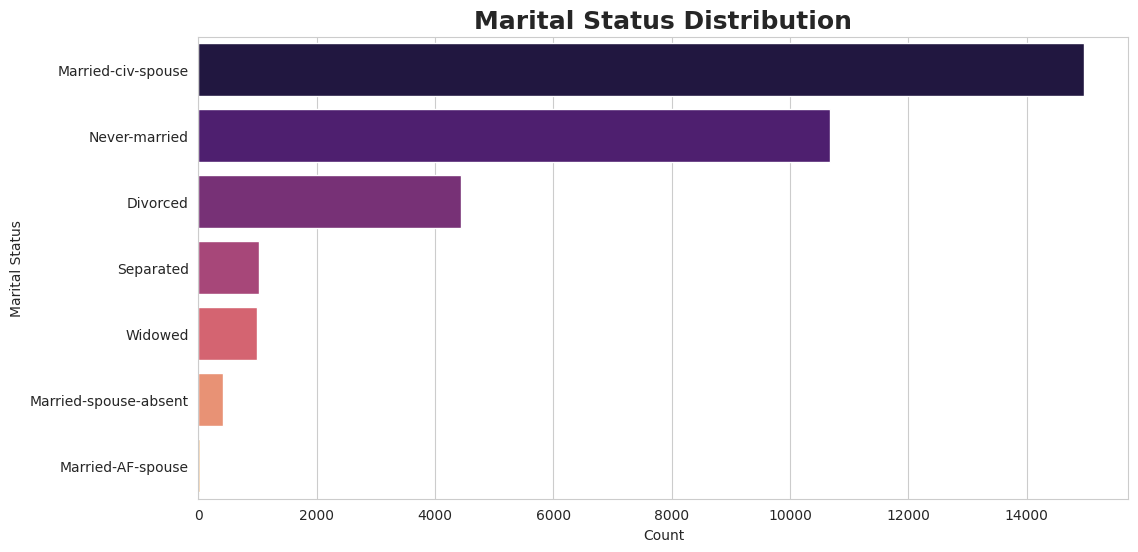

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='marital-status',
    order=df['marital-status'].value_counts().index,
    palette='magma'
)

plt.title(
    "Marital Status Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Count")

plt.ylabel("Marital Status")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Married individuals represent the largest group.
- Never-married individuals also account for a significant portion.
- Marital status may influence income levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

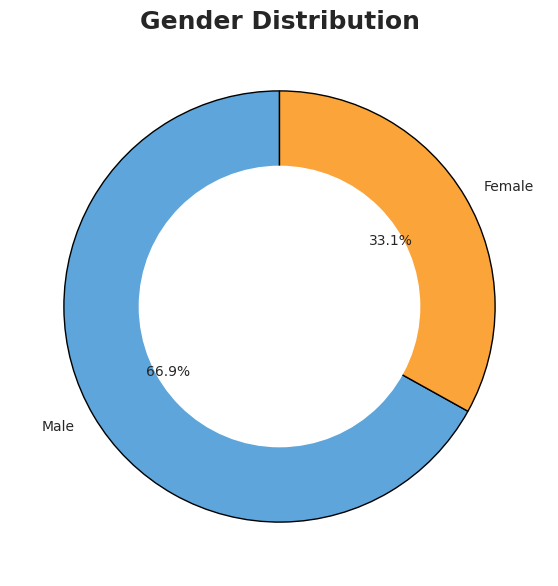

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(7,7))

colors=['#5DA5DA','#FAA43A']

plt.pie(
    df['sex'].value_counts(),
    labels=df['sex'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)

centre_circle=plt.Circle((0,0),0.65,fc='white')

fig=plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title(
    "Gender Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- The dataset contains both male and female individuals.
- Male observations are more frequent than female observations.
- Gender differences may contribute to variations in annual income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

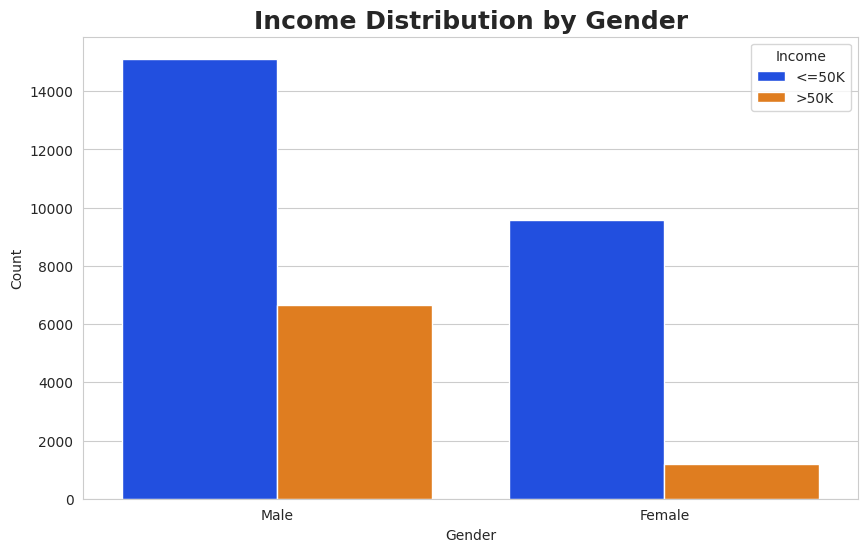

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='sex',
    hue='income',
    palette='bright'
)

plt.title(
    "Income Distribution by Gender",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Gender")

plt.ylabel("Count")

plt.legend(title="Income")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Male individuals have a higher proportion of income greater than **$50K**.
- Female individuals are more concentrated in the **<=50K** category.
- Gender appears to influence income distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

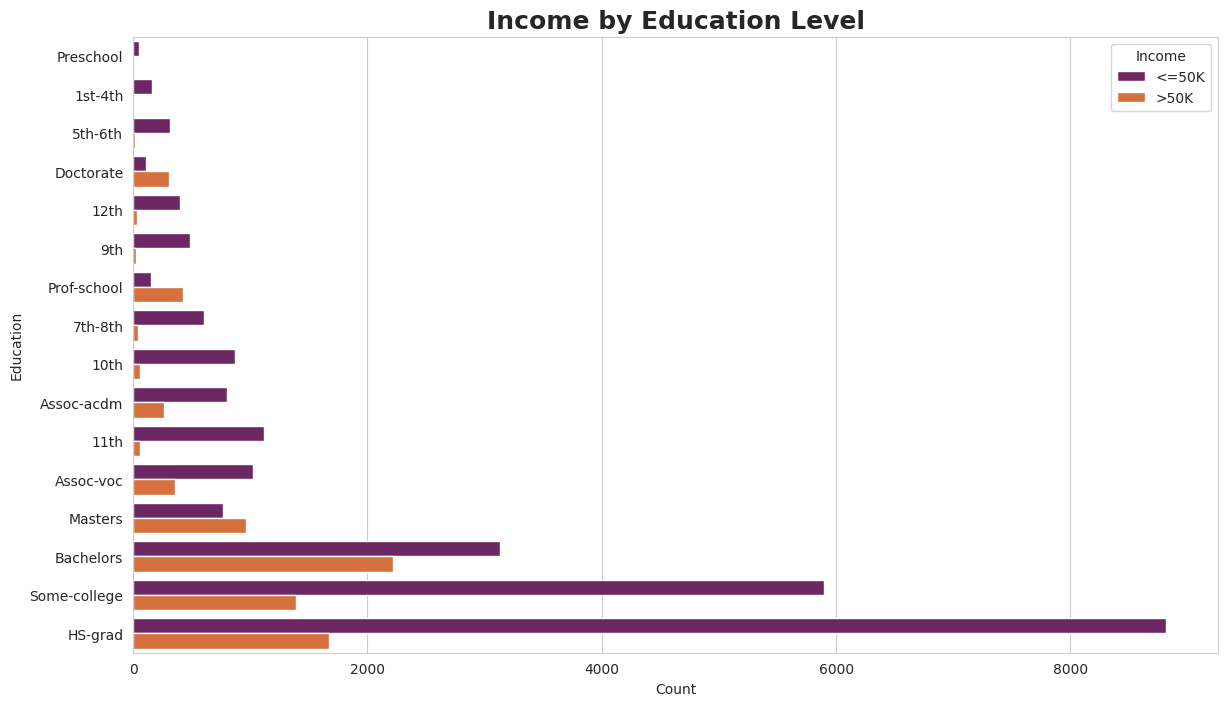

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(14,8))

order=df.groupby('education')['income'].count().sort_values().index

sns.countplot(
    data=df,
    y='education',
    hue='income',
    order=order,
    palette='inferno'
)

plt.title(
    "Income by Education Level",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Count")

plt.ylabel("Education")

plt.legend(title="Income")

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Individuals with Bachelor's, Master's, and Doctorate degrees have a higher proportion of income greater than **$50K**.
- Lower education levels are dominated by the **<=50K** income group.
- Education is strongly associated with earning potential.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

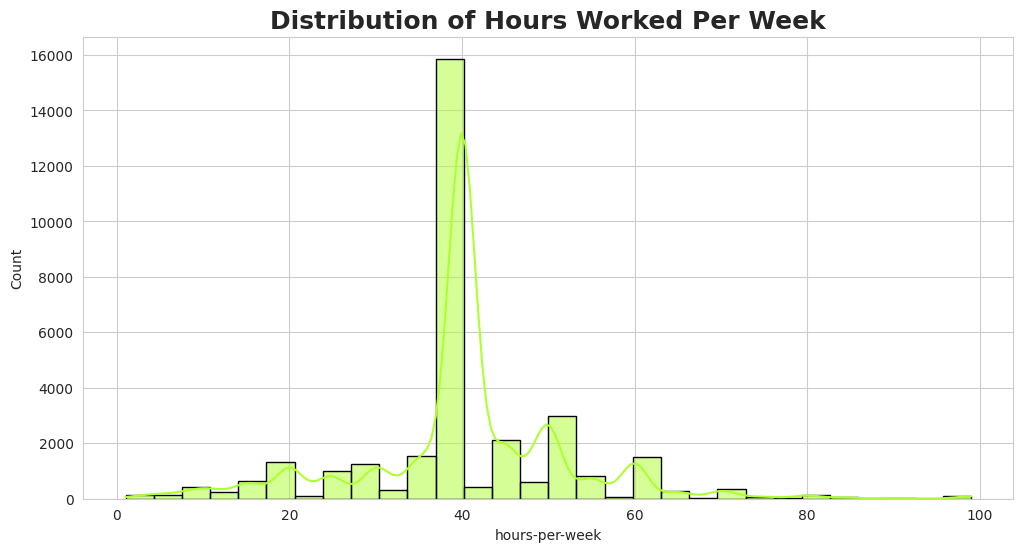

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(12,6))

sns.histplot(
    df['hours-per-week'],
    bins=30,
    kde=True,
    color='greenyellow',
    edgecolor='black'
)

plt.title(
    "Distribution of Hours Worked Per Week",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Most individuals work around **40 hours per week**.
- A smaller number of people work significantly longer hours.
- Working hours may influence annual income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

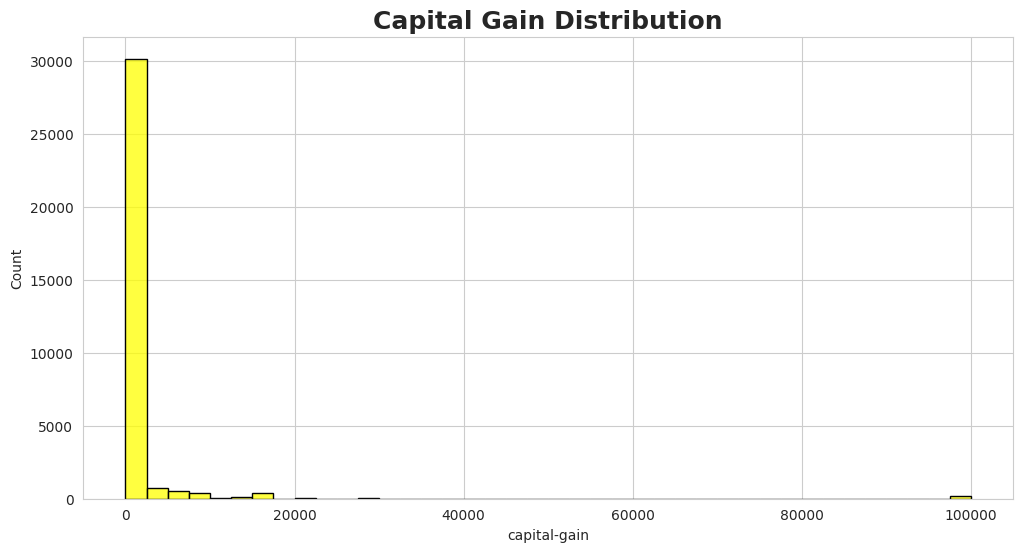

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(12,6))

sns.histplot(
    df['capital-gain'],
    bins=40,
    color='yellow',
    edgecolor='black'
)

plt.title(
    "Capital Gain Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Most individuals have zero capital gain.
- A few observations have extremely high capital gains.
- The feature is highly right-skewed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

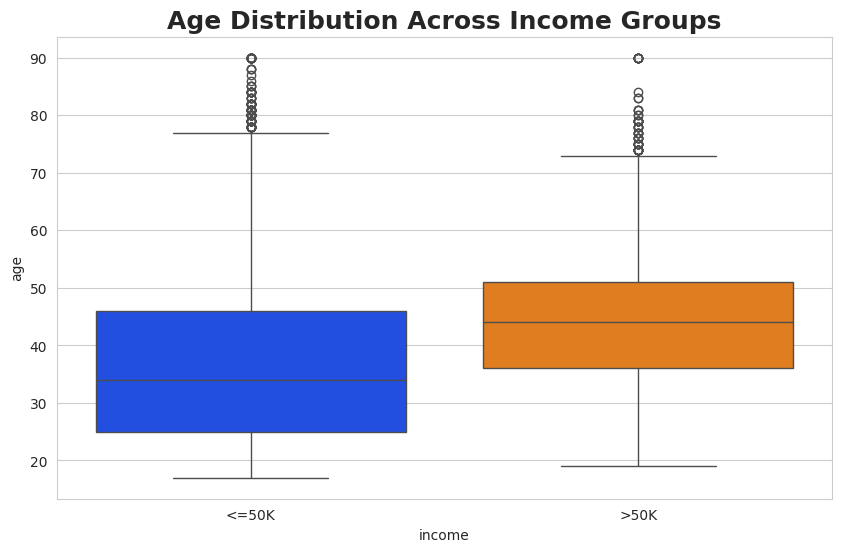

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='income',
    y='age',
    palette='bright'
)

plt.title(
    "Age Distribution Across Income Groups",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Individuals earning more than **$50K** tend to be older.
- The higher-income group has a higher median age.
- Several age outliers are present in both classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

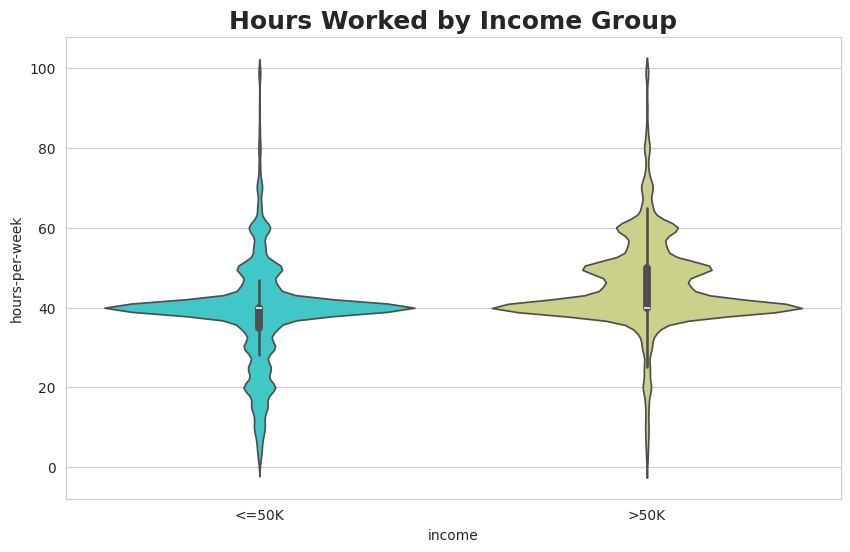

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='income',
    y='hours-per-week',
    palette='rainbow'
)

plt.title(
    "Hours Worked by Income Group",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Individuals earning more than **$50K** generally work longer hours.
- Most observations are concentrated around **40 hours per week**.
- The distribution differs slightly between income categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

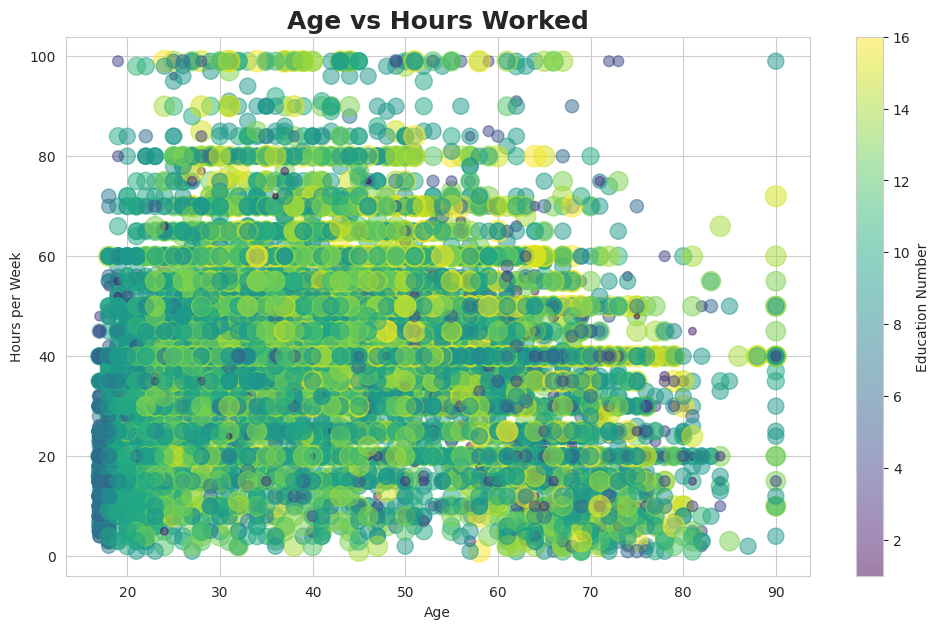

In [ ]:
plt.figure(figsize=(12,7))

sizes=df['education-num']*15

plt.scatter(
    df['age'],
    df['hours-per-week'],
    s=sizes,
    alpha=0.5,
    c=df['education-num'],
    cmap='viridis'
)

plt.colorbar(label='Education Number')

plt.xlabel("Age")

plt.ylabel("Hours per Week")

plt.title(
    "Age vs Hours Worked",
    fontsize=18,
    fontweight='bold'
)

plt.show()

### Observation

- Most individuals cluster around **30–50 years** and **40 working hours**.
- Bubble size represents education level.
- Higher education levels are visible across different age groups.

#### Chart - 14 - Correlation Heatmap

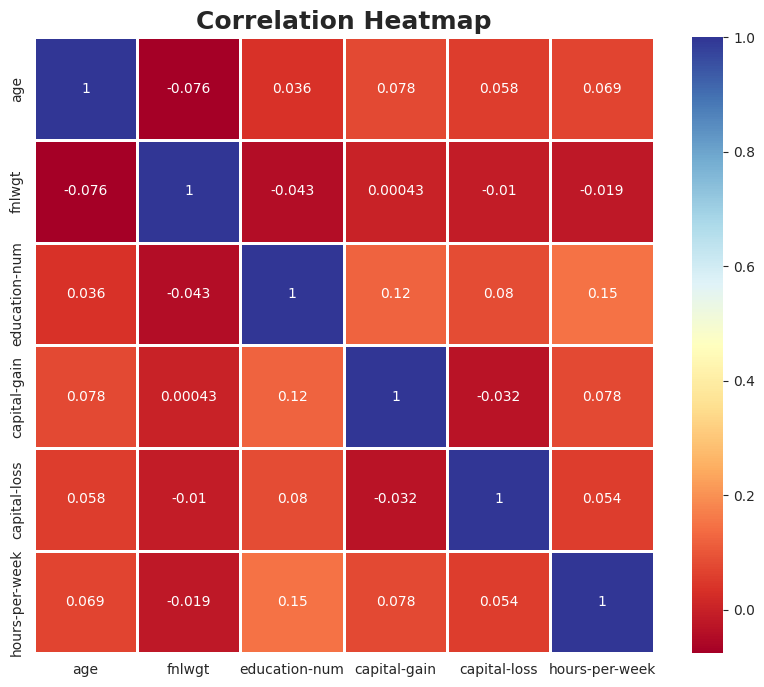

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,8))

corr=df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',
    linewidths=1
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Age and education show a moderate positive relationship with income-related features.
- Capital gain has one of the strongest positive relationships with higher income.
- Most numerical features have relatively low correlation with each other.

#### Chart - 15 - Pair Plot

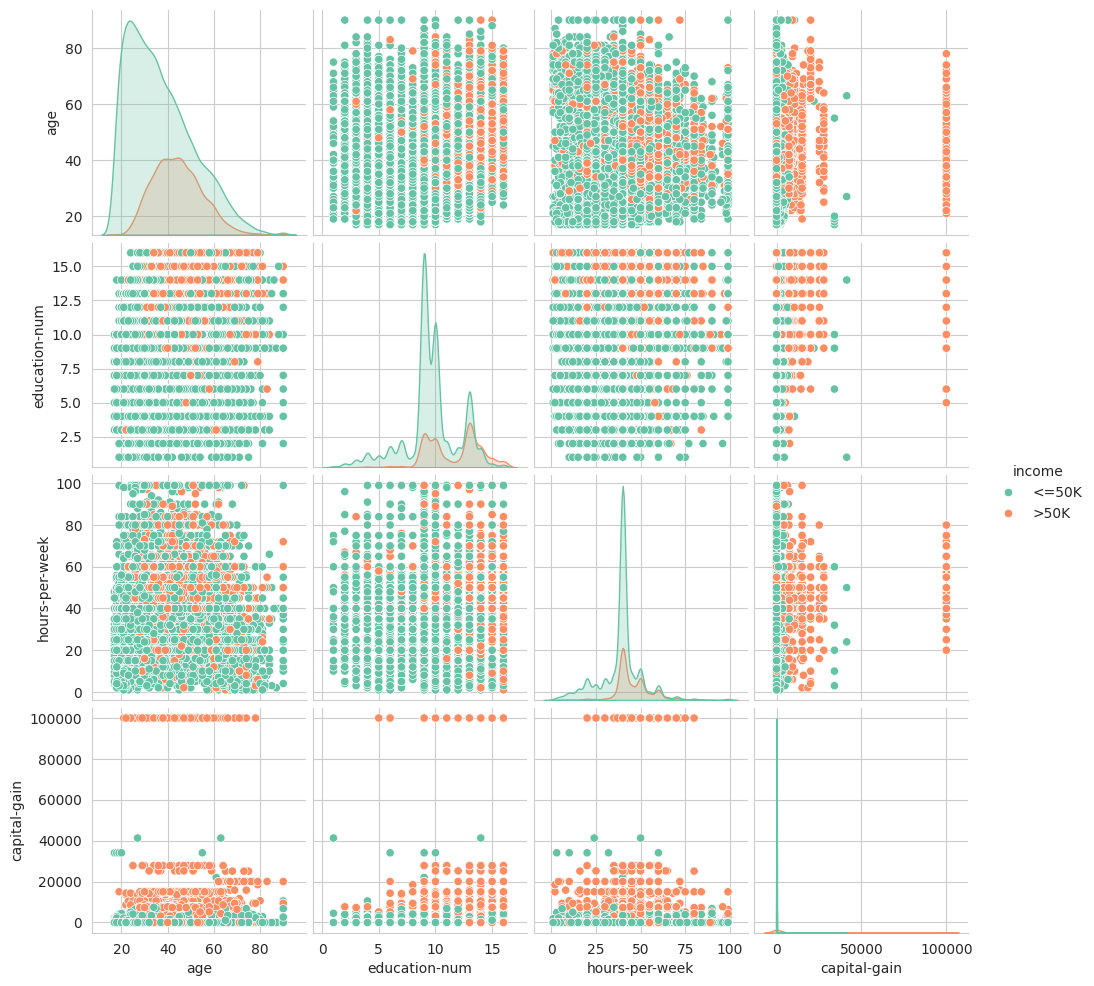

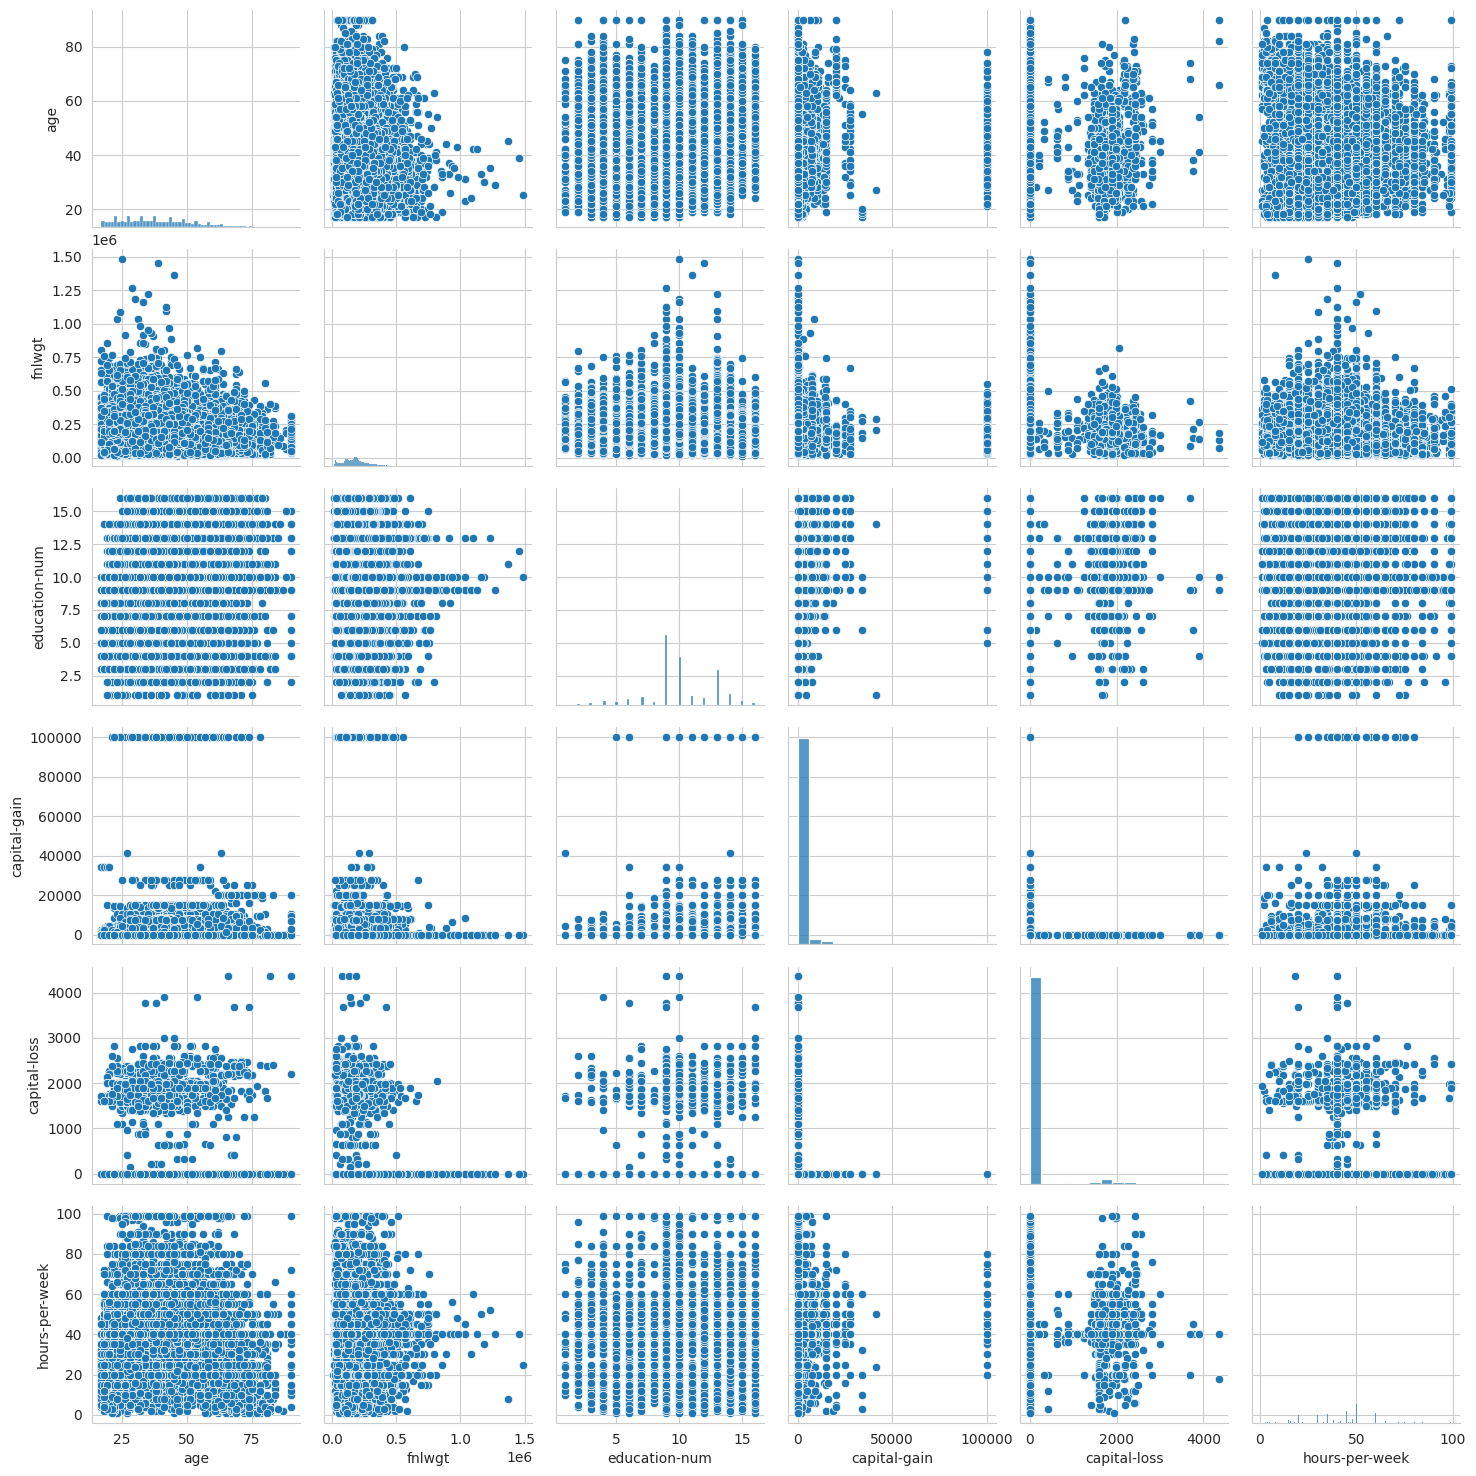

In [ ]:
# Pair Plot visualization code
sns.pairplot(
    df[
        [
            'age',
            'education-num',
            'hours-per-week',
            'capital-gain',
            'income'
        ]
    ],
    hue='income',
    palette='Set2'
)

plt.show()
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

### Observation

- Pairwise relationships reveal distinct patterns between the two income groups.
- Individuals earning more than **$50K** generally have higher education levels and capital gains.
- Pairplots help visualize feature interactions.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***